<img style="float: center;" src='./assets/jwebbinar.jpg' width="1000px"/> 

## JWebbinar 49
_June 25, 2026_
## Alignment Introduction 

### Author: Armin Rest (STScI), Justin Pierel (STScI)

**Purpose**:<BR>
This notebook contains a basic example of aligning a JWST image to a reference catalog, in this case Gaia. 

**Data**:<BR>
This example is set up to use an example dataset from early JWST NIRCam observations of the LMC, which is illustrative for these purposes. 


<hr style="border:1px solid gray"> </hr>

# Basic Example: The LMC

In [1]:
# Package imports
from jwst.datamodels import ImageModel
import re,os
from pathlib import Path
import jhat
import matplotlib.pyplot as plt
import os
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.io import fits
from astropy.wcs.utils import skycoord_to_pixel
from astropy import wcs
from astropy.nddata import extract_array
from astropy.visualization import (simple_norm,LinearStretch)


## If you have a CRDS issue, try uncommenting the following three lines
# os.environ["CRDS_PATH"] = os.path.expanduser("~/crds_cache/jwst")
# os.environ["CRDS_SERVER_URL"] = "https://jwst-crds.stsci.edu"

# os.makedirs(os.environ["CRDS_PATH"], exist_ok=True)

Maintenance with possible short-time disconnections: 29 June 2026 18:00–20:00 CEST
The following task in the stsci.skypac package can be run with TEAL:
                                    skymatch                                    


In [2]:
data_dir = Path(os.environ.get("JWEBBINAR_49_DATA", "../data"))
out_dir = Path(os.environ.get("JWEBBINAR_49_OUT", "../data"))
input_image = str(data_dir / 'jw01074003001_04101_00002_nrcalong_cal.fits')
outrootdir = str(out_dir / 'aligned')
outsubdir = 'lmc_example'
telescope = 'jwst'

wcs_align = jhat.st_wcs_align()
verbose=2
wcs_align.verbose=verbose

# first rough cut: best d_rotated+-rough_cut_pix. This is the upper limit for rough_cut
wcs_align.rough_cut_px_min = wcs_align.rough_cut_px_max = 1.5


In [3]:
wcs_align.set_outbasename(outrootdir=outrootdir,outsubdir=outsubdir,inputname=input_image)
# set the telescope
wcs_align.set_telescope(telescope=telescope,imname=input_image)


telescope set to jwst


### Let's examine the initial alignment relative to Gaia. We select a Gaia star position (you can try other star positions from the saved Gaia catalog after running the below cells). The red crosshair represents the Gaia star position, which we can see is significantly offset in NIRCam

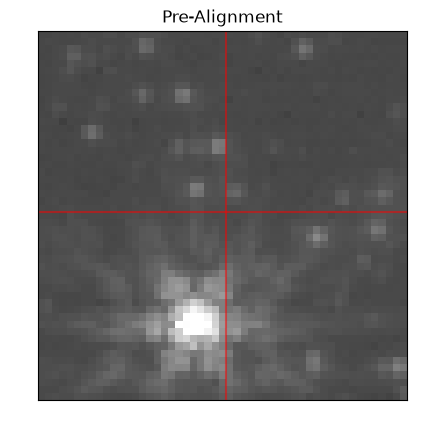

In [5]:
star_location = SkyCoord(80.53654603023910,-69.51877732495160,unit=u.deg)
ref_fits = fits.open(input_image)
ref_data = ref_fits['SCI',1].data
ref_y,ref_x = skycoord_to_pixel(star_location,wcs.WCS(ref_fits['SCI',1],ref_fits))

ref_cutout = extract_array(ref_data,(51,51),(ref_x,ref_y))

norm1 = simple_norm(ref_cutout,stretch='log',min_cut=-1,max_cut=200)

fig,axes = plt.subplots(1,1)
axes.imshow(ref_cutout, origin='lower',
                      norm=norm1,cmap='gray')
axes.set_title('Pre-Alignment')
axes.tick_params(labelcolor='none',axis='both',color='none')
axes.axvline(25.5,color='r',alpha=.5)
axes.axhline(25.5,color='r',alpha=.5)

plt.show()

### Now we run the photometry routine, which identifies sources in the target image to match to the reference catalog.

In [6]:
# do the photometry
xshift=0.0 
yshift=0.0 # This can be estimated if necessary by, e.g., comparing images in DS9 or identifying the stellar locus in later figures
wcs_align.phot.verbose = wcs_align.verbose
photfilename = f'{wcs_align.outbasename}.phot.txt'
(photfilename_4check,photcat_loaded) = wcs_align.phot.run_phot(input_image,
                                                          use_dq=True,
                                                          photfilename=photfilename,
                                                          xshift=xshift,
                                                          yshift=yshift,
                                                          overwrite=True)
# get the indices to the detections
ixs = wcs_align.phot.getindices()



### Doing photometry on ../data/jw01074003001_04101_00002_nrcalong_cal.fits
2 ../data/aligned/lmc_example/jw01074003001_04101_00002_nrcalong.phot.txt
photometry catalog filename: ../data/aligned/lmc_example/jw01074003001_04101_00002_nrcalong.phot.txt
photcat ../data/aligned/lmc_example/jw01074003001_04101_00002_nrcalong.phot.txt already exists, but recreating it since overwrite=True
Instrument: NIRCAM, aperture:NRCA5_FULL
Using DQ extension!!
Applying Pixel Area Map
find_stars
Finding stars --- Detector: NRCALONG, Filter: F277W
FWHM for the filter F277W: 1.444 px
Background and rms using MMMBackground and MADStdBackgroundRMS: 0.19043615 0.08437968

Number of sources found in the image: 47954
-------------------------------------



2026-06-24 15:15:27,604 - CRDS - INFO -  Calibration SW Found: jwst 2.0.1 (/Users/jpierel/miniconda3/envs/tweakreg/envs/jwebbinar/lib/python3.12/site-packages/jwst-2.0.1.dist-info)
model.meta.resample.pixel_scale_ratio was not found. Assuming the native detector pixel scale (i.e., pixel_scale_ratio = 1)


radii:[np.float32(2.1927404)]pixels radius_sky_in:7.0 radius_sky_out:12.0  radius_for_mag:[np.float32(2.1927404)]
Performing aperture photometry for radius r = 2.1927404403686523 px
Time Elapsed: 28.99334658301086
47386 objects left after removing entries with NaNs in mag or dmag column
dmag 0.36200000000000004
SNR_min cut: 46512 objects left after removing entries dmag>0.36200000000000004 (SNR<3.0)
46512 out of 47386 entries remain in photometry table
Saving ../data/aligned/lmc_example/jw01074003001_04101_00002_nrcalong.phot.txt


### Now comes matching between the target and reference catalogs (here Gaia).

In [7]:
dmag_max=None
sharpness_lim=(None,None)
roundness1_lim=(-0.75,0.75)
objmag_lim=(17,19)
Nbright=None
refmag_lim = (None,None)

# proper motion
# only for LMC: set pmflag to False
pmflag=False
pm_median=True

# make the initial cut on the image photometry catalog on magnitudes, sharpness, roundness etc
ixs_use = wcs_align.phot.initial_cut_photcat(dmag_max = dmag_max,
                                        sharpness_lim = sharpness_lim, # sharpness limits
                                        roundness1_lim = roundness1_lim, # roundness1 limits 
                                        objmag_lim = objmag_lim, # limits on mag, the magnitude of the objects in the image
                                        Nbright = Nbright,
                                        ixs=ixs)

# Note that refcatname='gaia' will automatically download and match to the Gaia catalog, but you can supply
# a filename here instead to match to your own reference catalog (we will do this in the next section.)
wcs_align.phot.load_and_match_refcat(ixs_obj=ixs_use,
                                refcatname='gaia',
                                refmag_lim=refmag_lim, # limits for initial cut
                                refmagerr_lim=(None,None), # limits for initial cut, needs to be added to options
                                refcolor_lim=(None,None), # limits for initial cut, needs to be added to options
                                pmflag = pmflag, 
                                pm_median=pm_median)

# Save the refcat entries!
refcatfilename = f'{wcs_align.outbasename}.refcat.txt'
print(f'Saving refcat file into {refcatfilename}')
wcs_align.phot.refcat.write(refcatfilename,overwrite=True)



########### !!!!!!!!!!  INITIAL CUT on image photometry cat: starting with 47386 objects
roundness1=(-0.75, 0.75) CUT:
roundness1 0.75
43561 left
objmag_lim=(17, 19) CUT:
mag 19
205 left
205 of image photometry objects pass initial cuts #1, 47181 cut
Getting gaia and matching it: ra=80.55683917516245 dec=-69.50145020331905 radius=0.03845266598556143 deg
RA/Dec columns in reference catalog:  ra1 dec1
INFO: Query finished. [astroquery.utils.tap.core]
Number of stars: 5578
### Applying proper motion correction to epoch mjd=59738.74162496701
adding median pm dRA=1.0373354705292104e-05 and dDec=7.329021607487095e-07
Number of stars after removing nan's: 5578
########### !!!!!!!!!!  INITIAL CUT on reference catalog: starting with 5578 objects
5578 of image photometry objects pass initial cuts #1, 0 cut
Matching reference catalog gaia
Using 205 image objects that are in x_idl=[-62.38,64.31] and y_idl=[-64.68,62.99] range
x 2008
y 2008
Keeping 1546 out of 5578 catalog objects within x=40.0-200

0

Try iterating with the parameters above to see what happens to the output plots. Increase the magnitude upper limit, the roundness/sharpness parameters, and generally get a feel for what impacts matching.

### Discussion point: Can you visually identify the stellar locus? If you choose a set of parameters that causes a failure in catalog matching, what can you do to improve things?

########### !!!!!!!!!!  INITIAL CUT on matched cat: starting with 205 objects
205 of image photometry objects pass initial cuts #1, 0 cut
dx median: 4.839273984710303
dy median: 15.89821601616427
*** Note: close plot to continue!


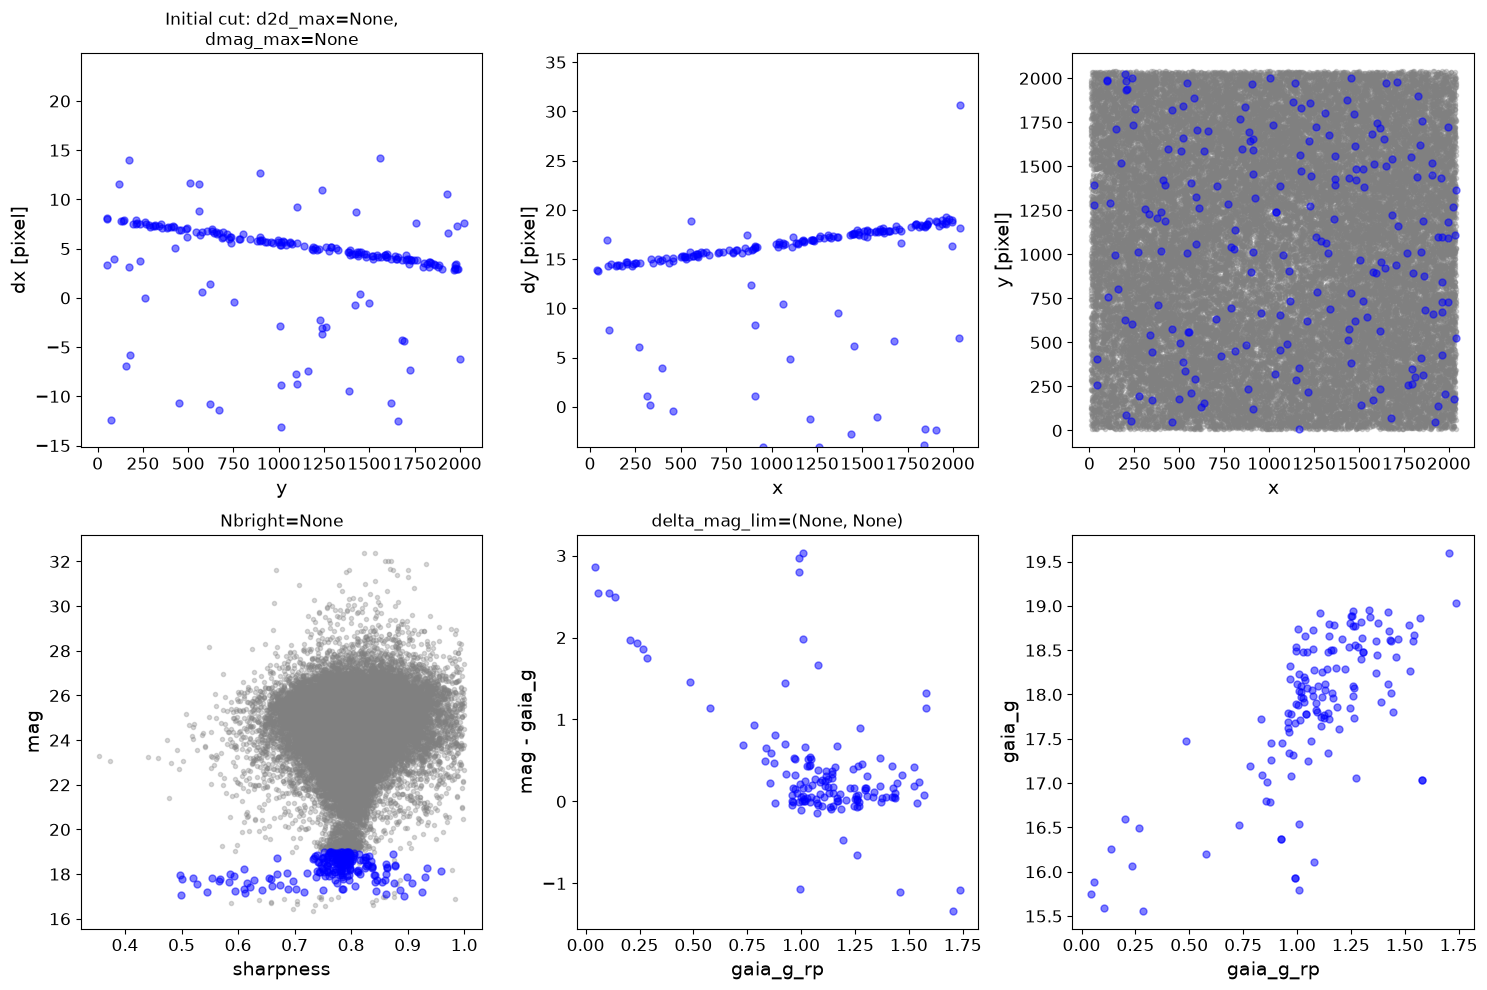

### Doing histogram cut for dx, slope_min:-0.008000 slope_max:0.008000 slope_stepsize:0.000800
Nfwhm=2.5, rough_cut_px_min=1.5, rough_cut_px_max=1.5, Nsigma=3.0
########################
### rotate dx versus y
Applying rolling gaussian:
gaussian_sigma_px=0.2, binsize=0.02, gaussian_sigma(bins)=10.0, windowsize(bins)=61 halfwindowsize(bins)=31
slope min: -0.008, slope max: 0.008, slope stepsize: slope_stepsize
####BEST:
  slope  intercept     maxval  index  d_bestguess  fwhm  multimax
-0.0024     2.4576 100.385501   3712     5.569342   0.7     False
Setting rough_cut_px=1.7499999999996518. limits: (1.5-1.5)
Setting rough_cut_px=1.5

####################
### d_rotated cut (rough_cut_px=1.5 pixels, Nsigma=3.0)
d_rot_tmp 7.069342375895744

rough_cut_px=1.5 pixels removes 60 from 205 entries
Keeping 145 out of 145, skippin 0 because of null values in columns d_rot_tmp
median: 5.546080
75.000000 percentile cut: max residual for cut: 0.242758
__tmp_residuals 0.24275820256328107
median: 5.54784

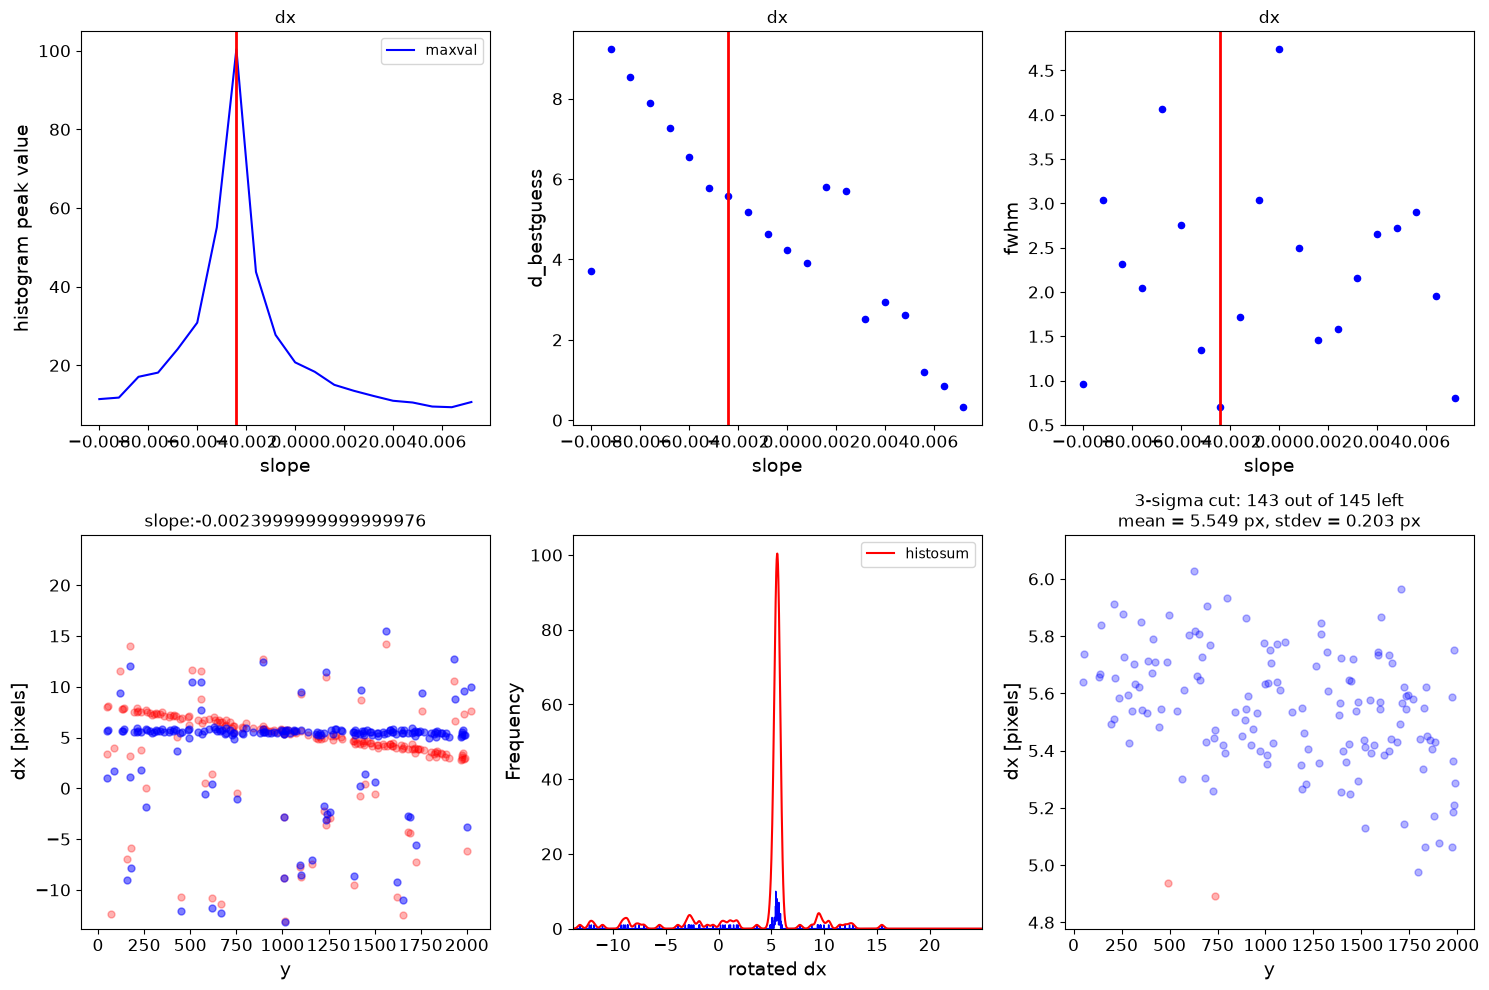

### Doing histogram cut for dy, slope_min:-0.008000 slope_max:0.008000 slope_stepsize:0.000800
Nfwhm=2.5, rough_cut_px_min=1.5, rough_cut_px_max=1.5, Nsigma=3.0
########################
### rotate dy versus x
Applying rolling gaussian:
gaussian_sigma_px=0.2, binsize=0.02, gaussian_sigma(bins)=10.0, windowsize(bins)=61 halfwindowsize(bins)=31
slope min: -0.008, slope max: 0.008, slope stepsize: slope_stepsize
####BEST:
 slope  intercept     maxval  index  d_bestguess  fwhm  multimax
0.0024    -2.4576 106.907393   1036    16.471531  0.62     False
Setting rough_cut_px=1.549999999999967. limits: (1.5-1.5)
Setting rough_cut_px=1.5

####################
### d_rotated cut (rough_cut_px=1.5 pixels, Nsigma=3.0)
d_rot_tmp 17.971531469202187

rough_cut_px=1.5 pixels removes 1 from 143 entries
Keeping 142 out of 142, skippin 0 because of null values in columns d_rot_tmp
median: 16.461366
75.000000 percentile cut: max residual for cut: 0.218092
__tmp_residuals 0.218091992198719
median: 16.464084
i

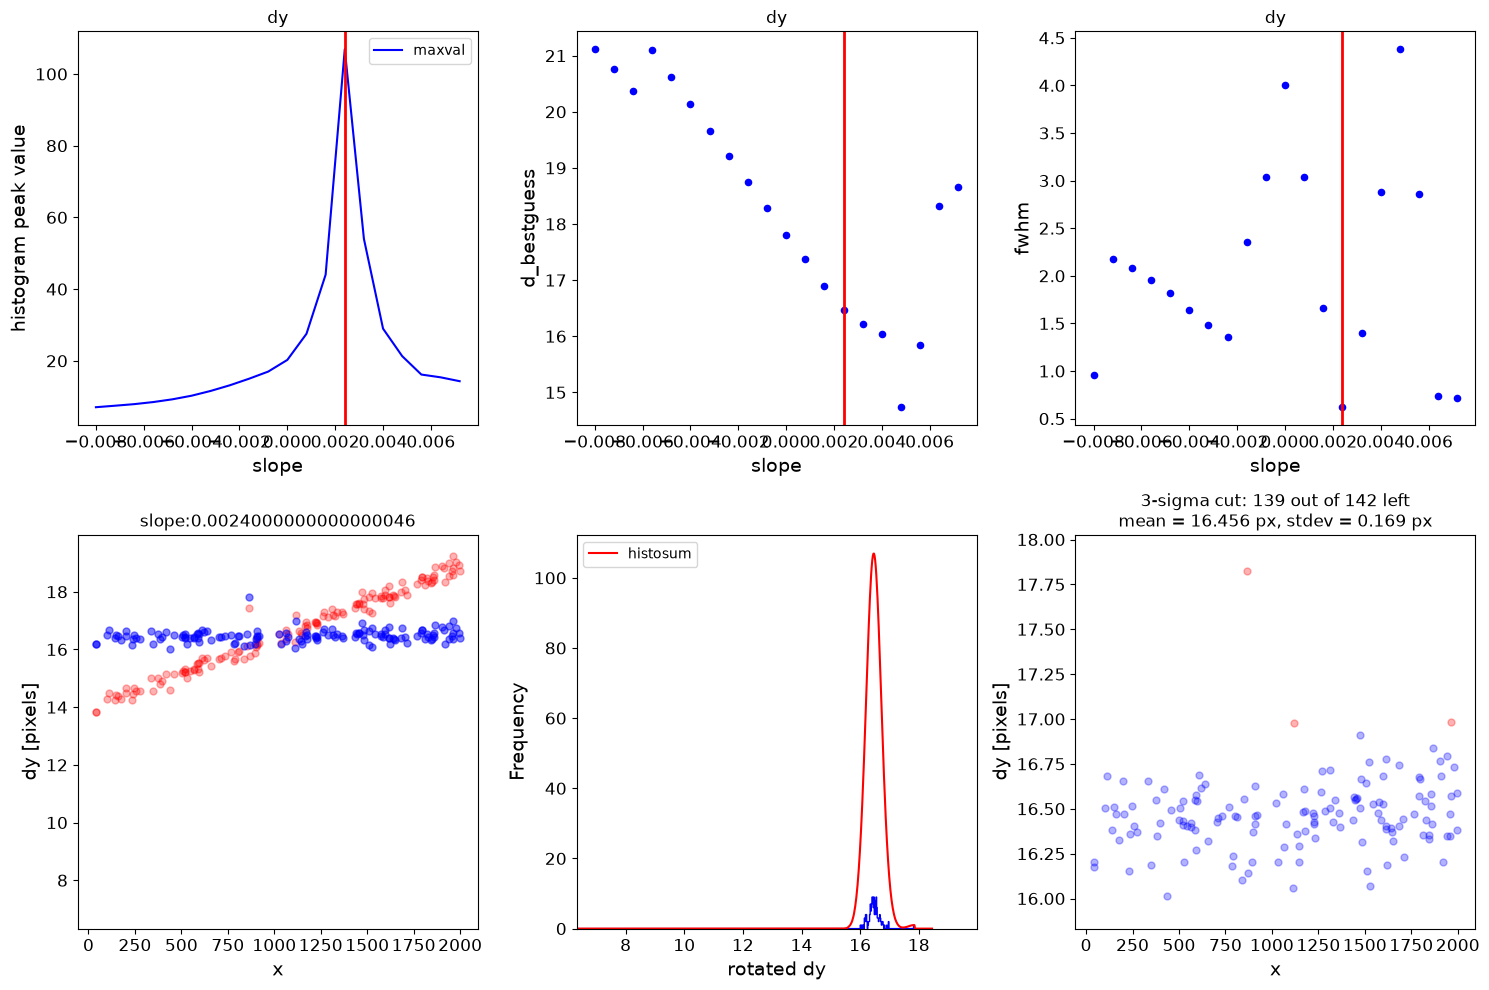

*** Note: close plots to continue!


<Figure size 640x480 with 0 Axes>

In [8]:
# maximum distance between source in image and refcat object, in arcsec 
d2d_max = None
# maximum uncertainty
dmag_max = None
# limits on color of image mag and reference color magnitude
delta_mag_lim =(None,None)
slope_min=-0.008
slope_Nsteps = 20 # slope_max=-slope_min, slope_stepsize=(slope_max-slope_min)/slope_Nsteps
Nfwhm = 2.5
show_initial_plot=1
show_histofit_plots=2
savephottable=True
outbasename=wcs_align.outbasename


ixs_bestmatch= wcs_align.find_good_refcat_matches(ixs=ixs_use,
                                             d2d_max = d2d_max,
                                             delta_mag_lim = delta_mag_lim, # limits on mag-refcat_mainfilter
                                             refmag_lim = refmag_lim, # limits on refcat_mainfilter, the magnitude of the reference catalog
                                             slope_min=slope_min, 
                                             slope_Nsteps = slope_Nsteps, # slope_max=-slope_min, slope_stepsize=(slope_max-slope_min)/slope_Nsteps
                                             show_initial_plot=show_initial_plot,
                                             show_histofit_plots=show_histofit_plots,
                                             savephottable=savephottable,
                                             outbasename=outbasename
                                             )     


### Actually apply the matched catalog to correct the target image.

139 matches are passed to tweakreg rshift fitting
Setting output directory for jw01074003001_04101_00002_nrcalong_jhat.fits file to ../data/aligned/lmc_example
Fitting tweakreg fitgeometry=rshift to xy=x,y to ra,dec=gaia_ra,gaia_dec
replacing SIP ../data/aligned/lmc_example/jw01074003001_04101_00002_nrcalong_jhat.fits
Saving ../data/aligned/lmc_example/jw01074003001_04101_00002_nrcalong_jhat.phot.prewcs.png


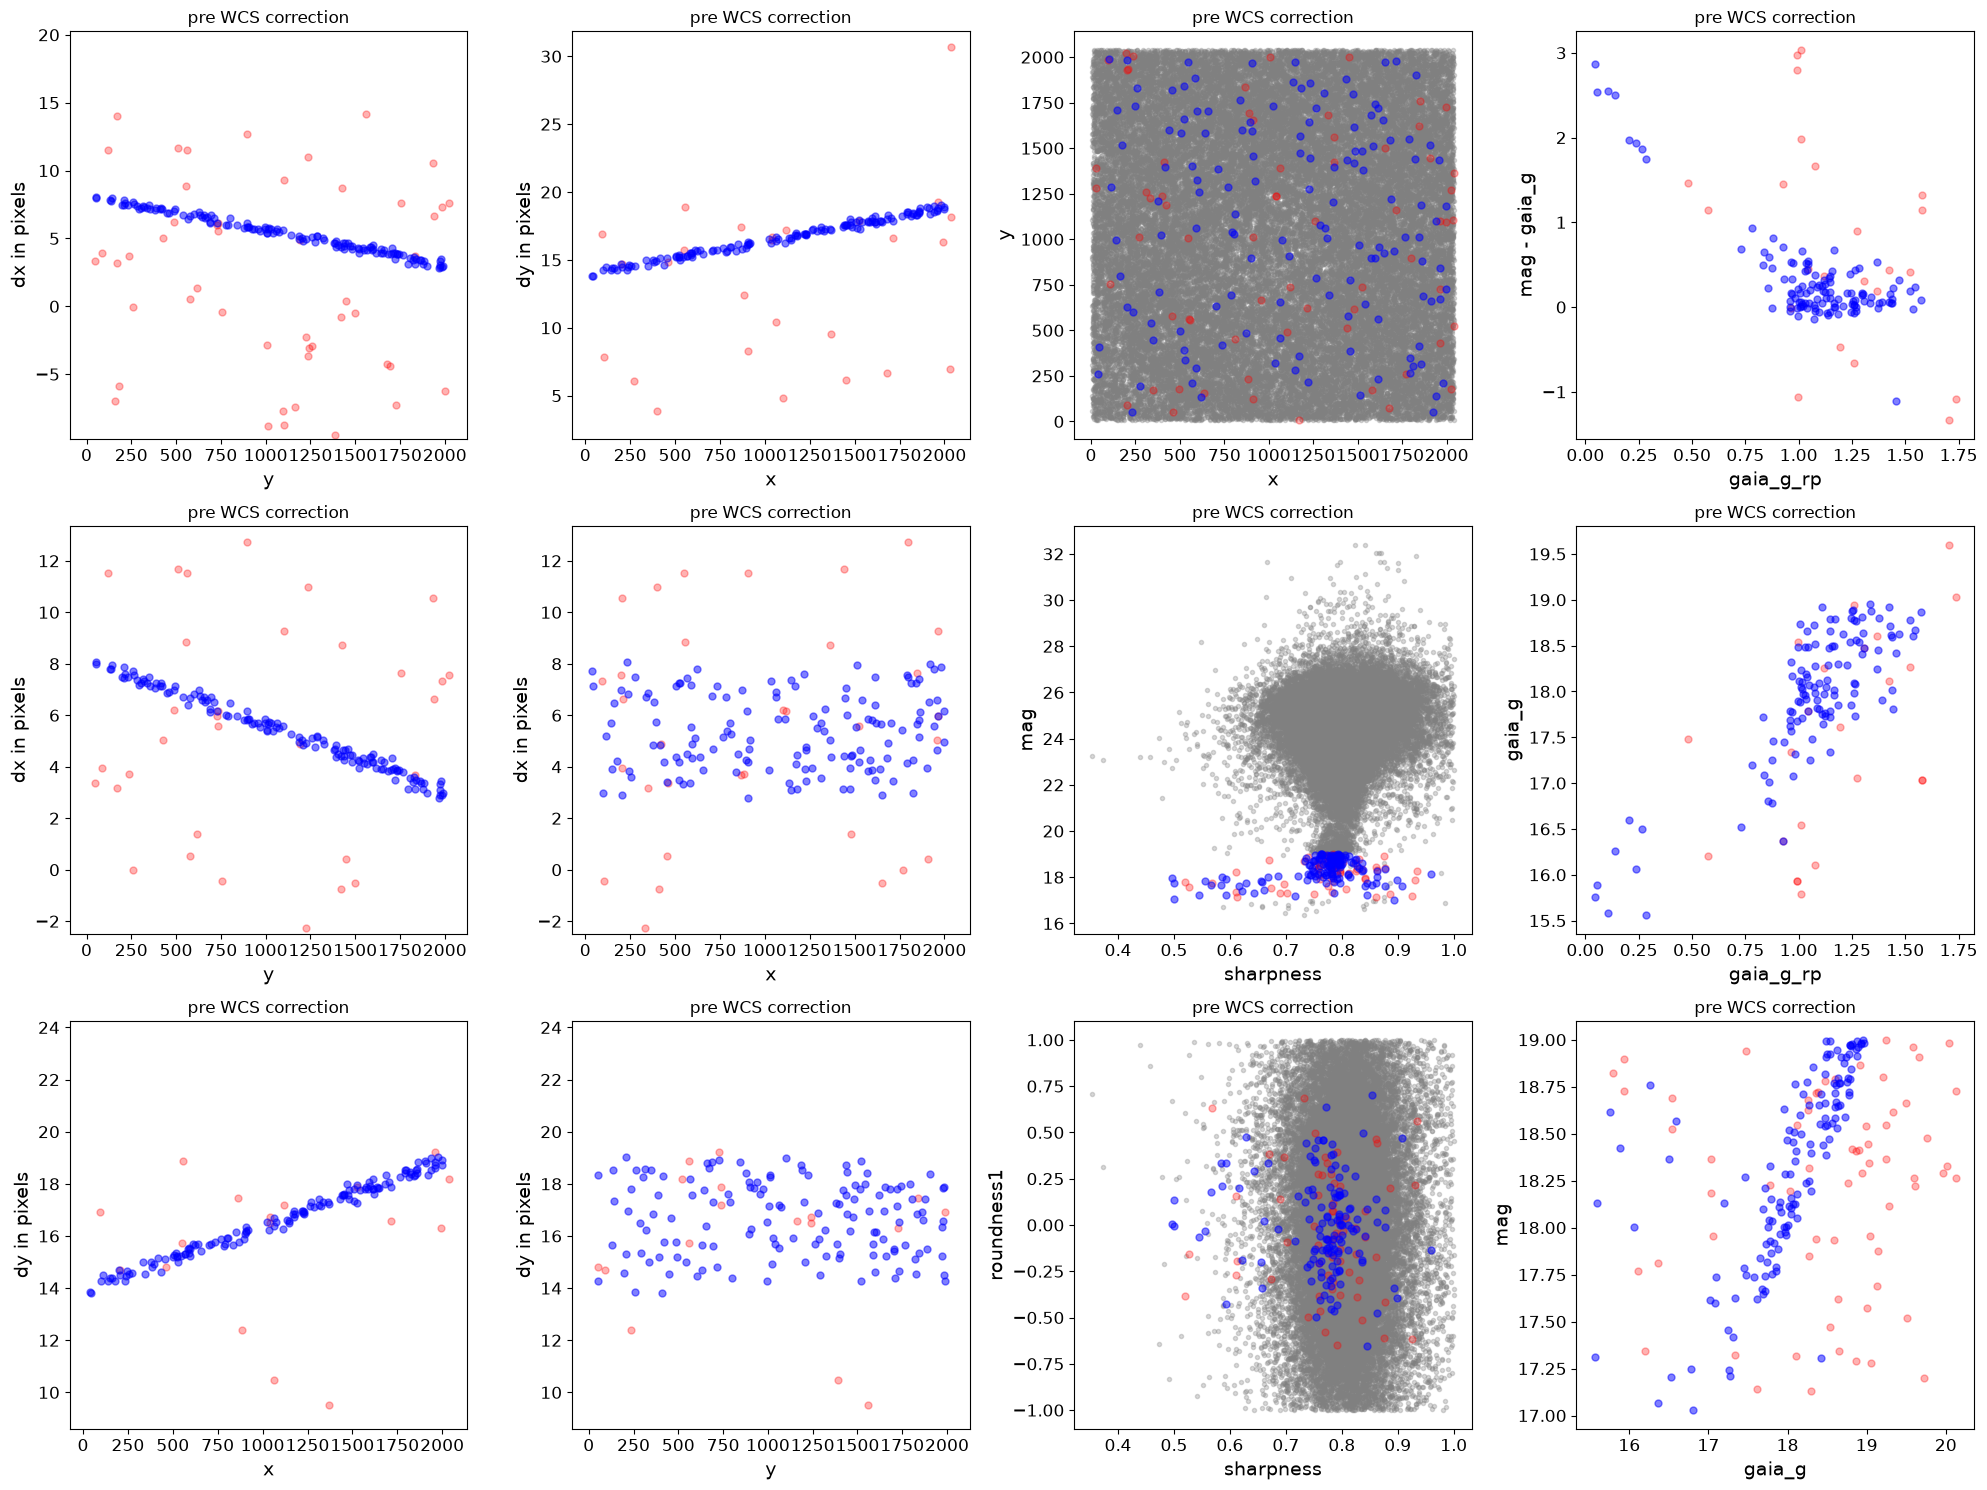

../data/aligned/lmc_example/jw01074003001_04101_00002_nrcalong_jhat.fits
Saving ../data/aligned/lmc_example/jw01074003001_04101_00002_nrcalong_jhat.good.phot.txt
Saving ../data/aligned/lmc_example/jw01074003001_04101_00002_nrcalong_jhat.phot.finalwcs.png


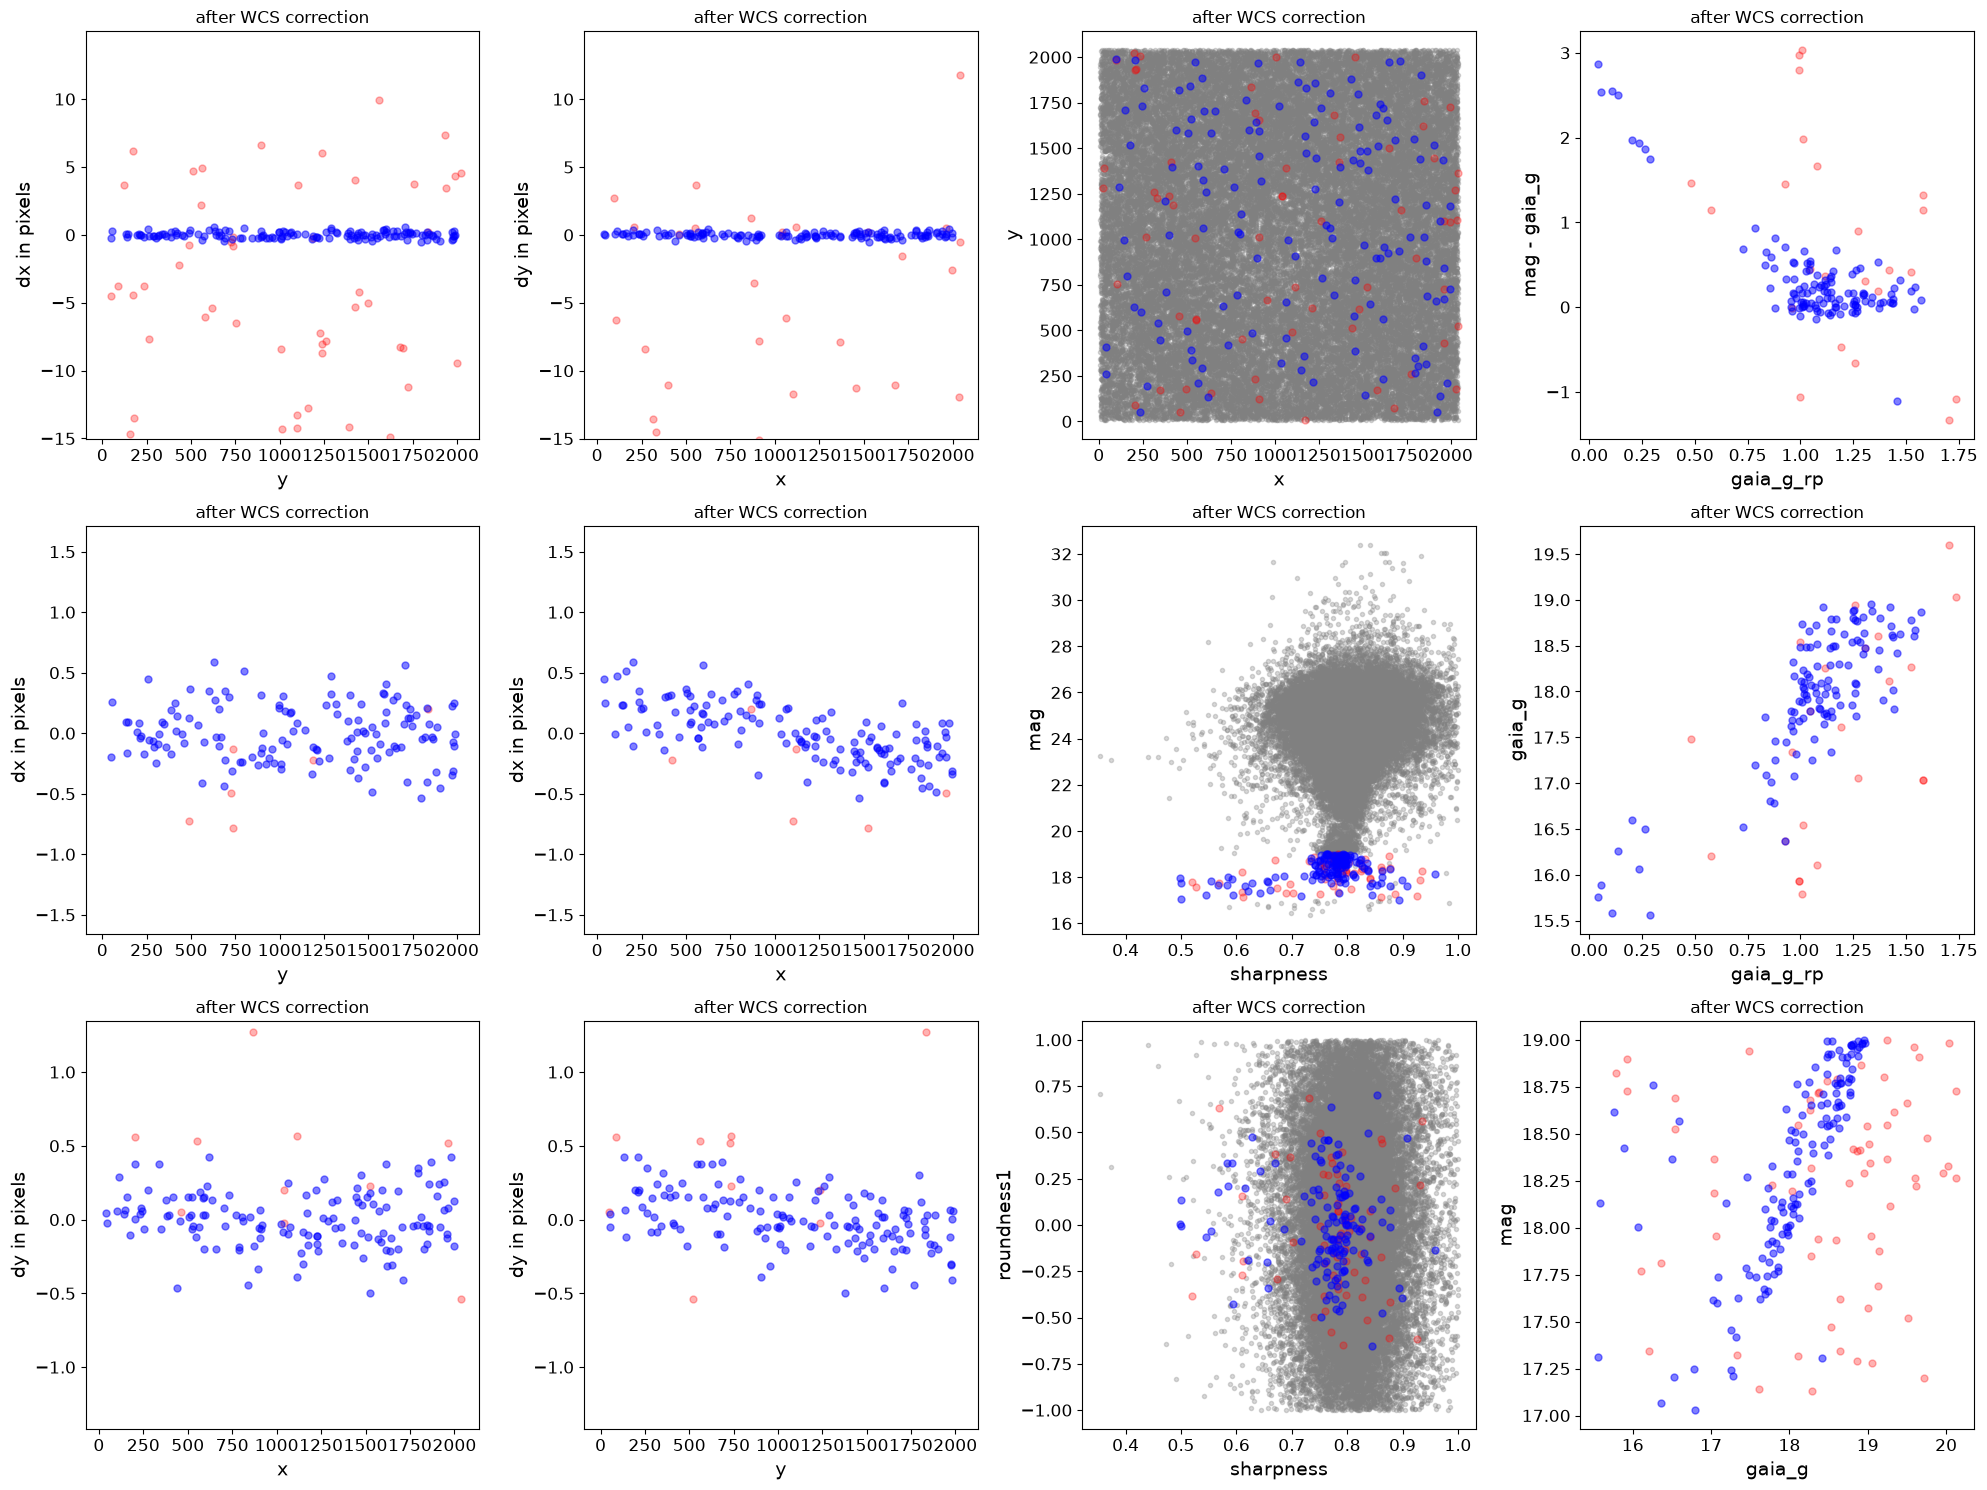

In [9]:
import os

workdir = os.path.join(os.path.expanduser('~'), 'jhat_workdir')
os.makedirs(workdir, exist_ok=True)

# Symlink input image
input_image_local = os.path.join(workdir, os.path.basename(input_image))
if os.path.exists(input_image_local) or os.path.islink(input_image_local):
    os.remove(input_image_local)
os.symlink(input_image, input_image_local)

# Symlink all sidecar files from the wcs_align output directory
catdir = os.path.dirname(wcs_align.outbasename)
for f in os.listdir(catdir):
    link = os.path.join(workdir, f)
    if os.path.exists(link) or os.path.islink(link):
        os.remove(link)
    os.symlink(os.path.join(catdir, f), link)

showplots = 1
saveplots = 1
savephottable = 1
jhatfits = f'{wcs_align.outbasename}_jhat.fits'

(runflag, jhatfits) = wcs_align.run_align2refcat(
    input_image_local,
    outputfits=jhatfits,
    ixs=ixs_bestmatch,
    overwrite=True
)

wcs_align.update_phottable_final_wcs(jhatfits,
                                    ixs_bestmatch = ixs_bestmatch,
                                    showplots=showplots,
                                    saveplots=saveplots,
                                    savephottable=savephottable,
                                    # overwrite=True
                                    )


## You can now rerun the above cells with different parameter choices and see how this impacts the final "after WCS correction" plots. Below is the same star as above, now compared with the aligned image position.

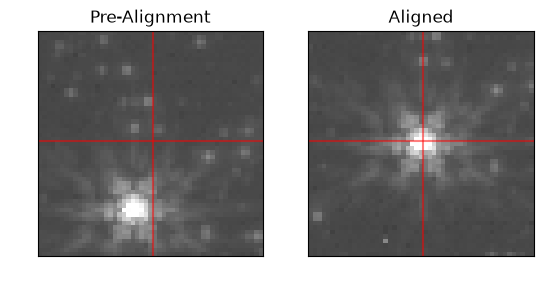

In [10]:
align_fits = fits.open(jhatfits)
align_data = align_fits['SCI',1].data
align_y,align_x = skycoord_to_pixel(star_location,wcs.WCS(align_fits['SCI',1],align_fits))

align_cutout = extract_array(align_data,(51,51),(align_x,align_y))
norm2 = simple_norm(align_cutout,stretch='log',min_cut=-1,max_cut=200)
fig,axes = plt.subplots(1,2)
axes[0].imshow(ref_cutout, origin='lower',
                      norm=norm1,cmap='gray')
axes[1].imshow(align_cutout, origin='lower',
                      norm=norm2,cmap='gray')
axes[0].set_title('Pre-Alignment')
axes[1].set_title('Aligned')
axes[0].tick_params(labelcolor='none',axis='both',color='none')
axes[1].tick_params(labelcolor='none',axis='both',color='none')
axes[0].axvline(25.5,color='r',alpha=.5)
axes[0].axhline(25.5,color='r',alpha=.5)
axes[1].axvline(25.5,color='r',alpha=.5)
axes[1].axhline(25.5,color='r',alpha=.5)